## **Overview**

This notebook implements the **in-domain Model 1** pipeline for building damage assessment on **xBD**.

The workflow is organized into two stages:

1. **Stage A: Building localization**
   - Train a binary localization model on pre-disaster imagery
   - Predict building masks and convert them into object proposals

2. **Stage B: Building-level damage classification**
   - Generate contextual pre/post building crops from predicted proposals
   - Train a Siamese EfficientNet-based classifier to predict one of four damage classes:
     **no-damage, minor-damage, major-damage, destroyed**

The notebook includes:
- local data preparation for efficient Colab training
- localization training and evaluation
- predicted-object crop generation
- classifier training and evaluation
- end-to-end qualitative inference on full tiles


## **Environment Setup**

Install the required libraries, import dependencies, and mount Google Drive for dataset access and checkpoint storage.

In [ ]:
!pip -q install albumentations
!pip -q install timm

In [ ]:
import os

import re
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


## **Prepare Local Working Directory**

Copy the xBD archive and metadata from Google Drive to the local Colab runtime to speed up training and reduce Drive I/O overhead.

In [ ]:
DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/xBD_project")
LOCAL_ROOT = Path("/content/xbd_work")
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

TAR_PATH = DRIVE_PROJECT_ROOT / "train.tar"
LOCAL_TAR_PATH = LOCAL_ROOT / "train.tar"
DRIVE_META_ROOT = DRIVE_PROJECT_ROOT / "output" / "metadata"
LOCAL_META_ROOT = LOCAL_ROOT / "metadata"

print("Copying train.tar to /content ...")
os.system(f'cp "{TAR_PATH}" "{LOCAL_TAR_PATH}"')

print("Extracting train.tar ...")
os.system(f'tar -xf "{LOCAL_TAR_PATH}" -C "{LOCAL_ROOT}"')

print("Copying metadata ...")
os.system(f'rsync -ah "{DRIVE_META_ROOT}/" "{LOCAL_META_ROOT}/"')

print("Local data is ready.")

Copying train.tar to /content ...
Extracting train.tar ...
Copying metadata ...
Local data is ready.


## **Configuration and Data Splits**

Define paths, random seeds, core hyperparameters, and load the in-domain train/validation/test split.

In [ ]:
DATA_ROOT = LOCAL_ROOT / "train"
IMAGES_ROOT = DATA_ROOT / "images"
LABELS_ROOT = DATA_ROOT / "labels"
TARGETS_ROOT = DATA_ROOT / "targets"
META_ROOT = LOCAL_ROOT / "metadata"

LOC_SAVE_PATH_DRIVE = DRIVE_PROJECT_ROOT / "best_model1_localization.pth"

SPLIT_CSV = META_ROOT / "in_domain_split.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

SEG_NUM_CLASSES = 2
DAMAGE_NUM_CLASSES = 4
SEG_CLASS_NAMES = ["background", "building"]
DAMAGE_CLASS_NAMES = ["no-damage", "minor-damage", "major-damage", "destroyed"]

SEG_CROP_SIZE = 512
SEG_BATCH_SIZE = 32
NUM_WORKERS = 4

SEG_EPOCHS = 25
SEG_LR = 1e-4
LOC_EARLY_STOP_PATIENCE = 6

LOC_TRAIN_REPEATS = 2
LOC_BUILDING_PROB = 0.9

print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
df = pd.read_csv(SPLIT_CSV).copy()

def to_local_path(p, root):
    return str(root / Path(str(p).replace("\\", "/")).name)

df["pre_img"] = df["pre_path"].apply(lambda p: to_local_path(p, IMAGES_ROOT))
df["post_img"] = df["post_path"].apply(lambda p: to_local_path(p, IMAGES_ROOT))
df["pre_label_path"] = df["pre_label_path"].apply(lambda p: to_local_path(p, LABELS_ROOT))
df["post_label_path"] = df["post_label_path"].apply(lambda p: to_local_path(p, LABELS_ROOT))
df["pre_target_path"] = df["pre_target_path"].apply(lambda p: to_local_path(p, TARGETS_ROOT))
df["post_target_path"] = df["post_target_path"].apply(lambda p: to_local_path(p, TARGETS_ROOT))

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))
display(train_df[["sample_id", "pre_img", "post_img", "pre_target_path", "post_target_path", "split"]].head(3))

Train: 1946
Val: 417
Test: 418


,sample_id,pre_img,post_img,pre_target_path,post_target_path,split
0,socal-fire_00001182,/content/xbd_work/train/images/socal-fire_0000...,/content/xbd_work/train/images/socal-fire_0000...,/content/xbd_work/train/targets/socal-fire_000...,/content/xbd_work/train/targets/socal-fire_000...,train
1,hurricane-matthew_00000287,/content/xbd_work/train/images/hurricane-matth...,/content/xbd_work/train/images/hurricane-matth...,/content/xbd_work/train/targets/hurricane-matt...,/content/xbd_work/train/targets/hurricane-matt...,train
2,socal-fire_00000572,/content/xbd_work/train/images/socal-fire_0000...,/content/xbd_work/train/images/socal-fire_0000...,/content/xbd_work/train/targets/socal-fire_000...,/content/xbd_work/train/targets/socal-fire_000...,train


## **Common Utility Functions**

Define reusable loss functions, metrics, and helpers shared across localization and classification stages.

In [ ]:
def building_mask_from_target(mask):
    return (mask > 0).astype(np.uint8)

def focal_loss(logits, targets, alpha=None, gamma=2.0):
    ce = F.cross_entropy(logits, targets, weight=alpha, reduction="none")
    pt = torch.exp(-ce)
    return (((1 - pt) ** gamma) * ce).mean()

def dice_loss(logits, targets, num_classes, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    inter = (probs * one_hot).sum((0, 2, 3))
    union = probs.sum((0, 2, 3)) + one_hot.sum((0, 2, 3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

def macro_f1_from_cm(cm):
    f1s = []
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = 2 * tp + fp + fn
        f1s.append((2 * tp) / denom if denom > 0 else np.nan)
    return float(np.nanmean(f1s)), f1s

def miou_from_cm(cm):
    ious = []
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else np.nan)
    return float(np.nanmean(ious)), ious

def inverse_freq_class_weights(labels, num_classes, device):
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    freqs = counts / counts.sum()
    inv = 1.0 / np.clip(freqs, 1e-8, None)
    inv = inv / inv.mean()
    return torch.tensor(inv, dtype=torch.float32, device=device)

# **Stage A: Building Localization**

Train a binary building-localization model on pre-disaster imagery to predict building masks that will later be converted into object proposals.

## **Localization Data Pipeline**

Build repeated building-aware random crops for training and full-tile datasets for validation and testing.

In [ ]:
def sample_crop_coords_building_aware(mask, crop_size=512, building_prob=0.8):
    h, w = mask.shape
    ys, xs = np.where(mask > 0)

    if len(ys) > 0 and np.random.rand() < building_prob:
        idx = np.random.randint(len(ys))
        cy, cx = ys[idx], xs[idx]
    else:
        cy = np.random.randint(0, h)
        cx = np.random.randint(0, w)

    y1 = int(np.clip(cy - crop_size // 2, 0, h - crop_size))
    x1 = int(np.clip(cx - crop_size // 2, 0, w - crop_size))
    y2 = y1 + crop_size
    x2 = x1 + crop_size
    return y1, y2, x1, x2

loc_train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

loc_val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

class XBDLocalizationTrainCropDataset(Dataset):
    def __init__(self, df, transform, crop_size=512, repeats=2, building_prob=0.9):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.crop_size = crop_size
        self.repeats = repeats
        self.building_prob = building_prob

    def __len__(self):
        return len(self.df) * self.repeats

    def __getitem__(self, idx):
        row = self.df.iloc[idx % len(self.df)]

        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        mask = np.array(Image.open(row["pre_target_path"]))
        mask = building_mask_from_target(mask)

        y1, y2, x1, x2 = sample_crop_coords_building_aware(
            mask,
            crop_size=self.crop_size,
            building_prob=self.building_prob
        )

        pre = pre[y1:y2, x1:x2]
        mask = mask[y1:y2, x1:x2]

        transformed = self.transform(image=pre, mask=mask)
        image = transformed["image"]
        mask = transformed["mask"].long()
        return image, mask

class XBDLocalizationFullTileDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        mask = np.array(Image.open(row["pre_target_path"]))
        mask = building_mask_from_target(mask)

        transformed = self.transform(image=pre, mask=mask)
        image = transformed["image"]
        mask = transformed["mask"].long()

        return image, mask

In [ ]:
loc_train_ds = XBDLocalizationTrainCropDataset(
    train_df,
    loc_train_transform,
    crop_size=SEG_CROP_SIZE,
    repeats=LOC_TRAIN_REPEATS,
    building_prob=LOC_BUILDING_PROB
)
loc_val_ds = XBDLocalizationFullTileDataset(val_df, loc_val_transform)
loc_test_ds = XBDLocalizationFullTileDataset(test_df, loc_val_transform)

loc_train_loader = DataLoader(
    loc_train_ds,
    batch_size=SEG_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

loc_val_loader = DataLoader(
    loc_val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

loc_test_loader = DataLoader(
    loc_test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

## **Localization Model**

Define the EfficientNet-based U-Net-style localization network, together with the optimization setup and training loop.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class LocalizationEfficientUNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.encoder = timm.create_model(
            "efficientnet_b1",
            pretrained=True,
            features_only=True,
            in_chans=3,
            out_indices=(0, 1, 2, 3, 4)
        )
        enc_channels = self.encoder.feature_info.channels()
        self.center = ConvBlock(enc_channels[-1], 256)
        self.up4 = UpBlock(256, enc_channels[3], 192)
        self.up3 = UpBlock(192, enc_channels[2], 128)
        self.up2 = UpBlock(128, enc_channels[1], 96)
        self.up1 = UpBlock(96, enc_channels[0], 64)
        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]
        feats = self.encoder(x)
        x = self.center(feats[-1])
        x = self.up4(x, feats[3])
        x = self.up3(x, feats[2])
        x = self.up2(x, feats[1])
        x = self.up1(x, feats[0])
        x = self.head(x)

        return F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)

In [ ]:
loc_class_weights = torch.tensor([0.2, 0.8], dtype=torch.float32, device=DEVICE)

def loc_loss_fn(logits, targets):
    fl = focal_loss(logits, targets, alpha=loc_class_weights, gamma=2.0)
    dl = dice_loss(logits, targets, num_classes=SEG_NUM_CLASSES)
    return fl + dl

In [ ]:
loc_model = LocalizationEfficientUNet(num_classes=SEG_NUM_CLASSES).to(DEVICE)

loc_optimizer = torch.optim.AdamW(loc_model.parameters(), lr=SEG_LR, weight_decay=1e-4)
loc_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    loc_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

loc_scaler = torch.amp.GradScaler('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def run_loc_epoch(loader, train=True):
    loc_model.train() if train else loc_model.eval()

    total_loss = 0.0
    cm = np.zeros((SEG_NUM_CLASSES, SEG_NUM_CLASSES), dtype=np.int64)

    pbar = tqdm(loader, desc="Loc Train" if train else "Loc Val", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        if train:
            loc_optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda', enabled=(DEVICE == "cuda")):
                logits = loc_model(imgs)
                loss = loc_loss_fn(logits, masks)

            if train:
                loc_scaler.scale(loss).backward()
                loc_scaler.step(loc_optimizer)
                loc_scaler.update()

        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy().ravel()
        targets = masks.detach().cpu().numpy().ravel()
        cm += confusion_matrix(targets, preds, labels=list(range(SEG_NUM_CLASSES)))

    epoch_loss = total_loss / len(loader.dataset)
    macro_f1, _ = macro_f1_from_cm(cm)
    miou, _ = miou_from_cm(cm)

    return {
        "loss": epoch_loss,
        "macro_f1": macro_f1,
        "miou": miou
    }

## **Train Localization Model**

Train the binary localization model, monitor validation performance, and save the best checkpoint.

In [ ]:
best_loc_val = -1
best_loc_epoch = -1
epochs_no_improve = 0
loc_save_path = "/content/best_model1_localization.pth"

loc_history = {
    "train_loss": [],
    "train_macro_f1": [],
    "train_miou": [],
    "val_loss": [],
    "val_macro_f1": [],
    "val_miou": []
}

for epoch in range(SEG_EPOCHS):
    train_metrics = run_loc_epoch(loc_train_loader, train=True)
    val_metrics = run_loc_epoch(loc_val_loader, train=False)

    loc_scheduler.step(val_metrics["macro_f1"])

    loc_history["train_loss"].append(train_metrics["loss"])
    loc_history["train_macro_f1"].append(train_metrics["macro_f1"])
    loc_history["train_miou"].append(train_metrics["miou"])
    loc_history["val_loss"].append(val_metrics["loss"])
    loc_history["val_macro_f1"].append(val_metrics["macro_f1"])
    loc_history["val_miou"].append(val_metrics["miou"])

    print(
        f"[LOC] Epoch {epoch+1:02d}/{SEG_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_f1={train_metrics['macro_f1']:.4f} | "
        f"train_mIoU={train_metrics['miou']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_metrics['macro_f1']:.4f} | "
        f"val_mIoU={val_metrics['miou']:.4f}"
    )

    if val_metrics["macro_f1"] > best_loc_val:
        best_loc_val = val_metrics["macro_f1"]
        best_loc_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(loc_model.state_dict(), loc_save_path)
        print(f"Saved best localization model to {loc_save_path}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= LOC_EARLY_STOP_PATIENCE:
        print("Localization early stopping triggered.")
        break

print("Best localization epoch:", best_loc_epoch)
print("Best localization val F1:", best_loc_val)

[LOC] Epoch 01/25 | train_loss=0.4129 | train_f1=0.7220 | train_mIoU=0.6060 | val_loss=0.4351 | val_f1=0.8573 | val_mIoU=0.7711
Saved best localization model to /content/best_model1_localization.pth


[LOC] Epoch 02/25 | train_loss=0.2887 | train_f1=0.8596 | train_mIoU=0.7715 | val_loss=0.4015 | val_f1=0.8848 | val_mIoU=0.8084
Saved best localization model to /content/best_model1_localization.pth


[LOC] Epoch 03/25 | train_loss=0.2327 | train_f1=0.8820 | train_mIoU=0.8025 | val_loss=0.3622 | val_f1=0.8859 | val_mIoU=0.8098
Saved best localization model to /content/best_model1_localization.pth


[LOC] Epoch 04/25 | train_loss=0.1912 | train_f1=0.8955 | train_mIoU=0.8220 | val_loss=0.3428 | val_f1=0.9002 | val_mIoU=0.8304
Saved best localization model to /content/best_model1_localization.pth


[LOC] Epoch 05/25 | train_loss=0.1683 | train_f1=0.9024 | train_mIoU=0.8322 | val_loss=0.3228 | val_f1=0.9033 | val_mIoU=0.8349
Saved best localization model to /content/best_model1_localization.pth


...

[LOC] Epoch 21/25 | train_loss=0.0994 | train_f1=0.9292 | train_mIoU=0.8734 | val_loss=0.2255 | val_f1=0.9230 | val_mIoU=0.8646
Saved best localization model to /content/best_model1_localization.pth


[LOC] Epoch 22/25 | train_loss=0.0990 | train_f1=0.9291 | train_mIoU=0.8733 | val_loss=0.2249 | val_f1=0.9235 | val_mIoU=0.8653
Saved best localization model to /content/best_model1_localization.pth


[LOC] Epoch 23/25 | train_loss=0.0994 | train_f1=0.9291 | train_mIoU=0.8734 | val_loss=0.2240 | val_f1=0.9224 | val_mIoU=0.8636


[LOC] Epoch 24/25 | train_loss=0.0977 | train_f1=0.9300 | train_mIoU=0.8747 | val_loss=0.2215 | val_f1=0.9232 | val_mIoU=0.8648


[LOC] Epoch 25/25 | train_loss=0.0967 | train_f1=0.9308 | train_mIoU=0.8761 | val_loss=0.2254 | val_f1=0.9248 | val_mIoU=0.8673
Saved best localization model to /content/best_model1_localization.pth
Best localization epoch: 25
Best localization val F1: 0.9247504910717366


In [ ]:
shutil.copy2(loc_save_path, LOC_SAVE_PATH_DRIVE)
print("Saved localization model to Drive:", LOC_SAVE_PATH_DRIVE)
print("Exists on Drive:", Path(LOC_SAVE_PATH_DRIVE).exists())

Saved localization model to Drive: /content/drive/MyDrive/xBD_project/best_model1_localization.pth
Exists on Drive: True


In [ ]:
loc_model.load_state_dict(torch.load(LOC_SAVE_PATH_DRIVE, map_location=DEVICE))
loc_model.eval()
print("Loaded localization model from Drive.")

Loaded localization model from Drive.


## **Evaluate Localization Model**

Visualize the training history and report final localization performance on the test split.

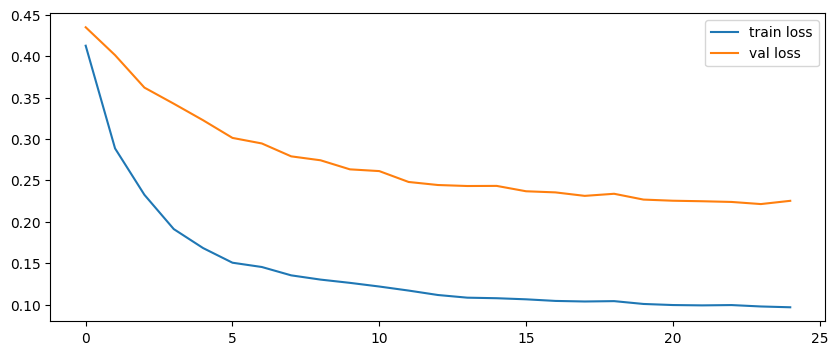

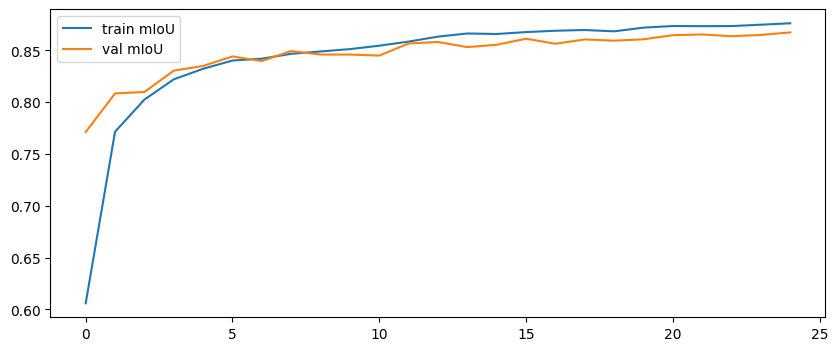

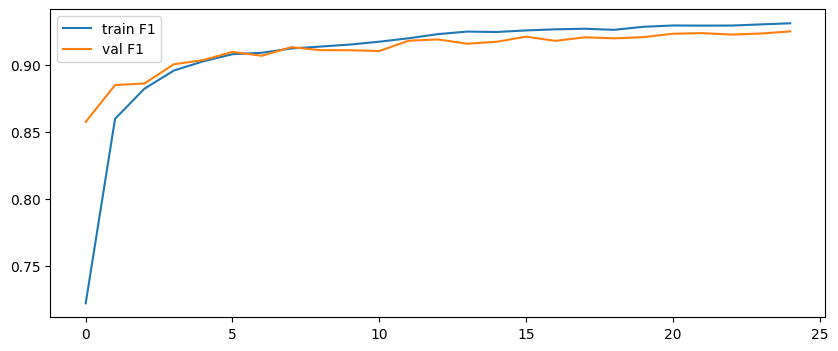

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(loc_history["train_loss"], label="train loss")
plt.plot(loc_history["val_loss"], label="val loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(loc_history["train_miou"], label="train mIoU")
plt.plot(loc_history["val_miou"], label="val mIoU")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(loc_history["train_macro_f1"], label="train F1")
plt.plot(loc_history["val_macro_f1"], label="val F1")
plt.legend()
plt.show()

In [ ]:
test_loc_metrics = run_loc_epoch(loc_test_loader, train=False)
print(test_loc_metrics)

{'loss': 0.2267059151698171, 'macro_f1': 0.9288075129816078, 'miou': 0.8733970807721312}


# **Stage B: Predicted-Object Crop Generation and Classification**

Configure the object-generation stage and the building-level classifier used for final damage prediction.

In [ ]:
CLS_IMG_SIZE = 224
CLS_BATCH_SIZE = 32
CLS_EPOCHS = 25
CLS_LR = 1e-4
CLS_WEIGHT_DECAY = 1e-4
CLS_EARLY_STOP_PATIENCE = 6

BACKBONE = "efficientnet_b1"

COMP_MIN_AREA = 10
MATCH_IOU_THRESH = 0.10
CONTEXT_PAD_FRAC = 0.20
CONTEXT_MIN_PAD = 12

LOC_BIN_THRESH = 0.60   # tune on val subset
USE_LOC_TTA = True

CLASS_NAME_TO_ID = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3,
}
ID_TO_CLASS_NAME = {v: k for k, v in CLASS_NAME_TO_ID.items()}

LOCAL_CLS_ROOT = Path("/content/model1c_work")
LOCAL_CLS_ROOT.mkdir(parents=True, exist_ok=True)

PREDOBJ_LOCAL_EXPORT_ROOT = LOCAL_CLS_ROOT / f"model1c_predobj_prepost_ctx_{CLS_IMG_SIZE}"
PREDOBJ_LOCAL_CSV = LOCAL_CLS_ROOT / f"model1c_predobj_prepost_ctx_{CLS_IMG_SIZE}.csv"
PREDOBJ_LOCAL_TAR = LOCAL_CLS_ROOT / f"model1c_predobj_prepost_ctx_{CLS_IMG_SIZE}.tar"

PREDOBJ_DRIVE_ROOT = DRIVE_PROJECT_ROOT / f"model1c_predobj_prepost_ctx_{CLS_IMG_SIZE}"
PREDOBJ_DRIVE_CSV = DRIVE_PROJECT_ROOT / "output" / "metadata" / f"model1c_predobj_prepost_ctx_{CLS_IMG_SIZE}.csv"
PREDOBJ_TAR_DRIVE = DRIVE_PROJECT_ROOT / f"model1c_predobj_prepost_ctx_{CLS_IMG_SIZE}.tar"

CLS_SAVE_PATH = "/content/best_model1c_siamese_classifier.pth"

## **Object Extraction Helpers**

Define functions for reading building polygons, matching predicted components to ground-truth objects, and creating contextual pre/post crops.

In [ ]:
def parse_wkt_polygon(wkt):
    match = re.match(r"POLYGON\s*\(\((.*)\)\)", wkt.strip())
    coords = []
    for pair in match.group(1).split(","):
        x_str, y_str = pair.strip().split()
        coords.append([float(x_str), float(y_str)])
    return np.array(coords, dtype=np.float32)

def polygon_mask_from_wkt(wkt, h, w):
    pts = parse_wkt_polygon(wkt)
    mask = np.zeros((h, w), dtype=np.uint8)
    pts = np.round(pts).astype(np.int32)
    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def load_uid_to_feature(label_json_path):
    with open(label_json_path, "r") as f:
        data = json.load(f)

    uid_map = {}
    for feat in data.get("features", {}).get("xy", []):
        props = feat.get("properties", {})
        if props.get("feature_type") != "building":
            continue

        uid = props.get("uid", None)
        if uid is not None:
            uid_map[uid] = feat

    meta = data.get("metadata", {})
    return uid_map, meta

In [ ]:
loc_model.eval()

@torch.no_grad()
def predict_loc_prob(pre_img_np):
    x = loc_val_transform(image=pre_img_np)["image"].unsqueeze(0).to(DEVICE)
    logits = loc_model(x)
    prob = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()
    return prob

@torch.no_grad()
def predict_loc_prob_tta(pre_img_np):
    probs = []

    # identity
    probs.append(predict_loc_prob(pre_img_np))

    # horizontal flip
    img = np.ascontiguousarray(np.fliplr(pre_img_np))
    probs.append(np.fliplr(predict_loc_prob(img)))

    # vertical flip
    img = np.ascontiguousarray(np.flipud(pre_img_np))
    probs.append(np.flipud(predict_loc_prob(img)))

    # rot90
    img = np.ascontiguousarray(np.rot90(pre_img_np, 1))
    probs.append(np.rot90(predict_loc_prob(img), -1))

    return np.mean(probs, axis=0)

@torch.no_grad()
def predict_loc_mask(pre_img_path, thresh=LOC_BIN_THRESH, use_tta=USE_LOC_TTA):
    pre = np.array(Image.open(pre_img_path).convert("RGB"))
    prob = predict_loc_prob_tta(pre) if use_tta else predict_loc_prob(pre)
    return (prob >= thresh).astype(np.uint8)

def clean_binary_mask(mask):
    mask = mask.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def connected_components_from_mask(binary_mask, min_area=25):
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask.astype(np.uint8), connectivity=8
    )
    comps = []

    for comp_id in range(1, n_labels):
        x = int(stats[comp_id, cv2.CC_STAT_LEFT])
        y = int(stats[comp_id, cv2.CC_STAT_TOP])
        w = int(stats[comp_id, cv2.CC_STAT_WIDTH])
        h = int(stats[comp_id, cv2.CC_STAT_HEIGHT])
        area = int(stats[comp_id, cv2.CC_STAT_AREA])

        if area < min_area:
            continue

        comp_mask = (labels == comp_id)
        comps.append({
            "comp_id": comp_id,
            "x1": x,
            "y1": y,
            "x2": x + w,
            "y2": y + h,
            "area": area,
            "mask": comp_mask
        })

    return comps

def bbox_from_binary_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1

def expand_box(x1, y1, x2, y2, width, height, pad_frac=0.20, min_pad=12):
    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)
    pad = max(min_pad, int(round(max(bw, bh) * pad_frac)))

    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(width, x2 + pad)
    y2 = min(height, y2 + pad)
    return x1, y1, x2, y2

def build_gt_objects(post_label_path):
    uid_map, meta = load_uid_to_feature(post_label_path)
    width = int(meta["width"])
    height = int(meta["height"])

    gt_objects = []
    for uid, feat in uid_map.items():
        subtype = feat["properties"]["subtype"]
        if subtype not in CLASS_NAME_TO_ID:
            continue

        gt_mask = polygon_mask_from_wkt(feat["wkt"], height, width).astype(bool)
        bbox = bbox_from_binary_mask(gt_mask)
        if bbox is None:
            continue

        gt_objects.append({
            "uid": uid,
            "label_name": subtype,
            "label": CLASS_NAME_TO_ID[subtype],
            "bbox": bbox,
            "mask": gt_mask
        })

    return gt_objects, width, height

def masks_iou(mask_a, mask_b, box_a, box_b):
    union_x1 = min(box_a[0], box_b[0])
    union_y1 = min(box_a[1], box_b[1])
    union_x2 = max(box_a[2], box_b[2])
    union_y2 = max(box_a[3], box_b[3])

    a_local = mask_a[union_y1:union_y2, union_x1:union_x2]
    b_local = mask_b[union_y1:union_y2, union_x1:union_x2]

    inter = np.logical_and(a_local, b_local).sum()
    if inter == 0:
        return 0.0

    union = np.logical_or(a_local, b_local).sum()
    return float(inter) / float(union + 1e-8)

def match_component_to_gt(comp, gt_objects, iou_thresh=0.10):
    best_gt = None
    best_iou = 0.0

    comp_box = (comp["x1"], comp["y1"], comp["x2"], comp["y2"])
    comp_mask = comp["mask"]

    for gt in gt_objects:
        iou = masks_iou(comp_mask, gt["mask"], comp_box, gt["bbox"])
        if iou > best_iou:
            best_iou = iou
            best_gt = gt

    if best_iou < iou_thresh:
        return None, 0.0

    return best_gt, best_iou

def make_context_crops(pre_img_np, post_img_np, comp_mask, pad_frac=0.20, min_pad=12):
    h, w = pre_img_np.shape[:2]
    bbox = bbox_from_binary_mask(comp_mask)
    if bbox is None:
        return None

    x1, y1, x2, y2 = expand_box(*bbox, w, h, pad_frac=pad_frac, min_pad=min_pad)

    pre_crop = pre_img_np[y1:y2, x1:x2].copy()
    post_crop = post_img_np[y1:y2, x1:x2].copy()
    mask_crop = (comp_mask[y1:y2, x1:x2].astype(np.uint8) * 255)

    return pre_crop, post_crop, mask_crop, (x1, y1, x2, y2)

In [ ]:
def export_model1c_predicted_crops(
    tile_df,
    export_root,
    csv_path,
    min_area=25,
    match_iou_thresh=0.10,
    pad_frac=0.20,
    min_pad=12
):
    export_root = Path(export_root)
    rows = []

    loc_mask_dir = export_root / "_loc_masks"
    loc_mask_dir.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(tile_df.iterrows(), total=len(tile_df)):
        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        post = np.array(Image.open(row["post_img"]).convert("RGB"))

        loc_mask = predict_loc_mask(row["pre_img"])
        loc_mask = clean_binary_mask(loc_mask)

        split_loc_dir = loc_mask_dir / row["split"]
        split_loc_dir.mkdir(parents=True, exist_ok=True)
        loc_mask_path = split_loc_dir / f"{row['sample_id']}_loc.png"
        Image.fromarray((loc_mask * 255).astype(np.uint8)).save(loc_mask_path)

        comps = connected_components_from_mask(loc_mask, min_area=min_area)
        gt_objects, width, height = build_gt_objects(row["post_label_path"])

        for comp_idx, comp in enumerate(comps):
            gt, best_iou = match_component_to_gt(comp, gt_objects, iou_thresh=match_iou_thresh)
            if gt is None:
                continue

            out = make_context_crops(
                pre, post, comp["mask"],
                pad_frac=pad_frac,
                min_pad=min_pad
            )
            if out is None:
                continue

            pre_crop, post_crop, mask_crop, (x1, y1, x2, y2) = out

            crop_id = f"{row['sample_id']}_c{comp_idx:03d}_u{gt['uid']}"
            out_dir = export_root / row["split"] / gt["label_name"]
            out_dir.mkdir(parents=True, exist_ok=True)

            pre_crop_path = out_dir / f"{crop_id}_pre.png"
            post_crop_path = out_dir / f"{crop_id}_post.png"
            mask_crop_path = out_dir / f"{crop_id}_mask.png"

            Image.fromarray(pre_crop).save(pre_crop_path)
            Image.fromarray(post_crop).save(post_crop_path)
            Image.fromarray(mask_crop).save(mask_crop_path)

            rows.append({
                "sample_id": row["sample_id"],
                "split": row["split"],
                "disaster_type": row["disaster_type"],
                "comp_idx": comp_idx,
                "matched_uid": gt["uid"],
                "match_iou": best_iou,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "label_name": gt["label_name"],
                "label": gt["label"],
                "pre_crop_path": str(pre_crop_path),
                "post_crop_path": str(post_crop_path),
                "mask_crop_path": str(mask_crop_path),
                "loc_mask_path": str(loc_mask_path),
            })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(csv_path, index=False)

    print("Saved CSV:", csv_path)
    print("Total matched predicted objects:", len(out_df))
    print()
    print(out_df["split"].value_counts())
    print()
    print(out_df["label_name"].value_counts())

    return out_df

## **Threshold Selection for Object Generation**

Evaluate candidate localization thresholds on a validation subset and choose the threshold that gives the best proposal quality for Stage B.

In [ ]:
@torch.no_grad()
def audit_thresholds_on_subset(tile_df, thresholds=(0.35, 0.40, 0.45, 0.50), max_tiles=100):
    rows = []
    subset = tile_df.iloc[:max_tiles].reset_index(drop=True)

    for thr in thresholds:
        stats = {
            "gt_total": 0,
            "pred_components": 0,
            "matched_components": 0,
            "unique_gt_matched": 0,
            "merged_components": 0
        }

        for _, row in tqdm(subset.iterrows(), total=len(subset), leave=False):
            gt_objects, _, _ = build_gt_objects(row["post_label_path"])
            stats["gt_total"] += len(gt_objects)

            loc_mask = predict_loc_mask(row["pre_img"], thresh=thr, use_tta=USE_LOC_TTA)
            loc_mask = clean_binary_mask(loc_mask)
            comps = connected_components_from_mask(loc_mask, min_area=COMP_MIN_AREA)
            stats["pred_components"] += len(comps)

            matched_uids = set()
            matched_components = 0
            merged_components = 0

            for comp in comps:
                comp_box = (comp["x1"], comp["y1"], comp["x2"], comp["y2"])
                overlaps = []

                for gt in gt_objects:
                    iou = masks_iou(comp["mask"], gt["mask"], comp_box, gt["bbox"])
                    if iou >= MATCH_IOU_THRESH:
                        overlaps.append((gt["uid"], iou))

                if len(overlaps) > 0:
                    matched_components += 1
                    best_uid = max(overlaps, key=lambda x: x[1])[0]
                    matched_uids.add(best_uid)

                if len(overlaps) > 1:
                    merged_components += 1

            stats["matched_components"] += matched_components
            stats["unique_gt_matched"] += len(matched_uids)
            stats["merged_components"] += merged_components

        rows.append({
            "threshold": thr,
            "gt_matched_recall": stats["unique_gt_matched"] / max(stats["gt_total"], 1),
            "component_match_rate": stats["matched_components"] / max(stats["pred_components"], 1),
            "pred_components": stats["pred_components"],
            "merged_components": stats["merged_components"]
        })

    return pd.DataFrame(rows)

In [ ]:
thr_df = audit_thresholds_on_subset(val_df, thresholds=(0.35, 0.40, 0.45, 0.50), max_tiles=100)
display(thr_df.sort_values("gt_matched_recall", ascending=False))

,threshold,gt_matched_recall,component_match_rate,pred_components,merged_components
3,0.50,0.503211,0.796690,2961,377
2,0.45,0.497860,0.792062,2948,381
1,0.40,0.494221,0.785617,2948,384
0,0.35,0.487800,0.772558,2959,376


In [ ]:
thr_df = audit_thresholds_on_subset(
    val_df,
    thresholds=(0.48, 0.50, 0.52, 0.55),
    max_tiles=200
)
display(thr_df.sort_values("gt_matched_recall", ascending=False))

,threshold,gt_matched_recall,component_match_rate,pred_components,merged_components
3,0.55,0.530791,0.829584,6267,915
2,0.52,0.529146,0.828827,6251,916
1,0.50,0.528220,0.826247,6256,913
0,0.48,0.526370,0.824952,6244,921


In [ ]:
thr_df = audit_thresholds_on_subset(
    val_df,
    thresholds=(0.58, 0.60),
    max_tiles=200
)
display(thr_df.sort_values("gt_matched_recall", ascending=False))

,threshold,gt_matched_recall,component_match_rate,pred_components,merged_components
1,0.60,0.534080,0.834795,6271,906
0,0.58,0.532744,0.832802,6268,910


## **Export Predicted-Object Crops**

Run the localization model on all tiles, convert predicted masks into building proposals, match them to ground-truth labels, and save the final pre/post contextual crop dataset.

In [ ]:
# RUN THIS ONCE ONLY TO BUILD CROPS LOCALLY IN /content

predobj_df = export_model1c_predicted_crops(
    df,
    export_root=PREDOBJ_LOCAL_EXPORT_ROOT,
    csv_path=PREDOBJ_LOCAL_CSV,
    min_area=COMP_MIN_AREA,
    match_iou_thresh=MATCH_IOU_THRESH,
    pad_frac=CONTEXT_PAD_FRAC,
    min_pad=CONTEXT_MIN_PAD
)

Saved CSV: /content/model1c_work/model1c_predobj_prepost_ctx_224.csv
Total matched predicted objects: 81219

split
train    57672
test     12631
val      10916
Name: count, dtype: int64

label_name
no-damage       54850
minor-damage     9800
major-damage     9620
destroyed        6949
Name: count, dtype: int64


## **Save Crop Dataset**

Archive the generated crop dataset and copy the final tar file and metadata CSV to Google Drive for reuse in later sessions.

In [ ]:
# RUN THIS ONCE TO CREATE THE TAR

export_root = Path(PREDOBJ_LOCAL_EXPORT_ROOT)
tar_path = Path(PREDOBJ_LOCAL_TAR)

os.system(
    f'tar -cf "{tar_path}" -C "{export_root.parent}" "{export_root.name}"'
)

print("Created local tar:", tar_path)
print("Tar size (GB):", round(tar_path.stat().st_size / 1024**3, 3))

Created local tar: /content/model1c_work/model1c_predobj_prepost_ctx_224.tar
Tar size (GB): 2.343


In [ ]:
# RUN THIS ONCE TO COPY THE TAR + CSV TO DRIVE

os.system(f'cp "{PREDOBJ_LOCAL_TAR}" "{PREDOBJ_TAR_DRIVE}"')
os.system(f'cp "{PREDOBJ_LOCAL_CSV}" "{PREDOBJ_DRIVE_CSV}"')

print("Copied tar to Drive:", PREDOBJ_TAR_DRIVE)
print("Copied CSV to Drive:", PREDOBJ_DRIVE_CSV)

Copied tar to Drive: /content/drive/MyDrive/xBD_project/model1c_predobj_prepost_ctx_224.tar
Copied CSV to Drive: /content/drive/MyDrive/xBD_project/output/metadata/model1c_predobj_prepost_ctx_224.csv


In [ ]:
print("Tar exists on Drive:", Path(PREDOBJ_TAR_DRIVE).exists())
print("CSV exists on Drive:", Path(PREDOBJ_DRIVE_CSV).exists())

if Path(PREDOBJ_TAR_DRIVE).exists():
    print("Tar size (GB):", round(Path(PREDOBJ_TAR_DRIVE).stat().st_size / 1024**3, 3))

Tar exists on Drive: True
CSV exists on Drive: True
Tar size (GB): 2.343


## **Restore Crop Dataset in a New Session**

Optional utility cell for reloading the exported crop dataset from Google Drive without rebuilding the crops.

In [ ]:
# NEW SESSION: copy tar to /content and load CSV from Drive

os.system(f'cp "{PREDOBJ_TAR_DRIVE}" "{PREDOBJ_LOCAL_TAR}"')
os.system(f'tar -xf "{PREDOBJ_LOCAL_TAR}" -C "{LOCAL_CLS_ROOT}"')

predobj_df = pd.read_csv(PREDOBJ_DRIVE_CSV)

In [ ]:
train_crop_df = predobj_df[predobj_df["split"] == "train"].reset_index(drop=True)
val_crop_df = predobj_df[predobj_df["split"] == "val"].reset_index(drop=True)
test_crop_df = predobj_df[predobj_df["split"] == "test"].reset_index(drop=True)

print("Train predicted-object crops:", len(train_crop_df))
print("Val predicted-object crops:", len(val_crop_df))
print("Test predicted-object crops:", len(test_crop_df))
print()
print(pd.crosstab(predobj_df["split"], predobj_df["label_name"]))

Train predicted-object crops: 57672
Val predicted-object crops: 10916
Test predicted-object crops: 12631

label_name  destroyed  major-damage  minor-damage  no-damage
split                                                       
test              917          1759          1600       8355
train            5193          6970          6619      38890
val               839           891          1581       7605


## **Crop Dataset Sanity Check**

Inspect a few sampled crop triplets (pre, post, mask) to verify crop quality and class labels before classifier training.

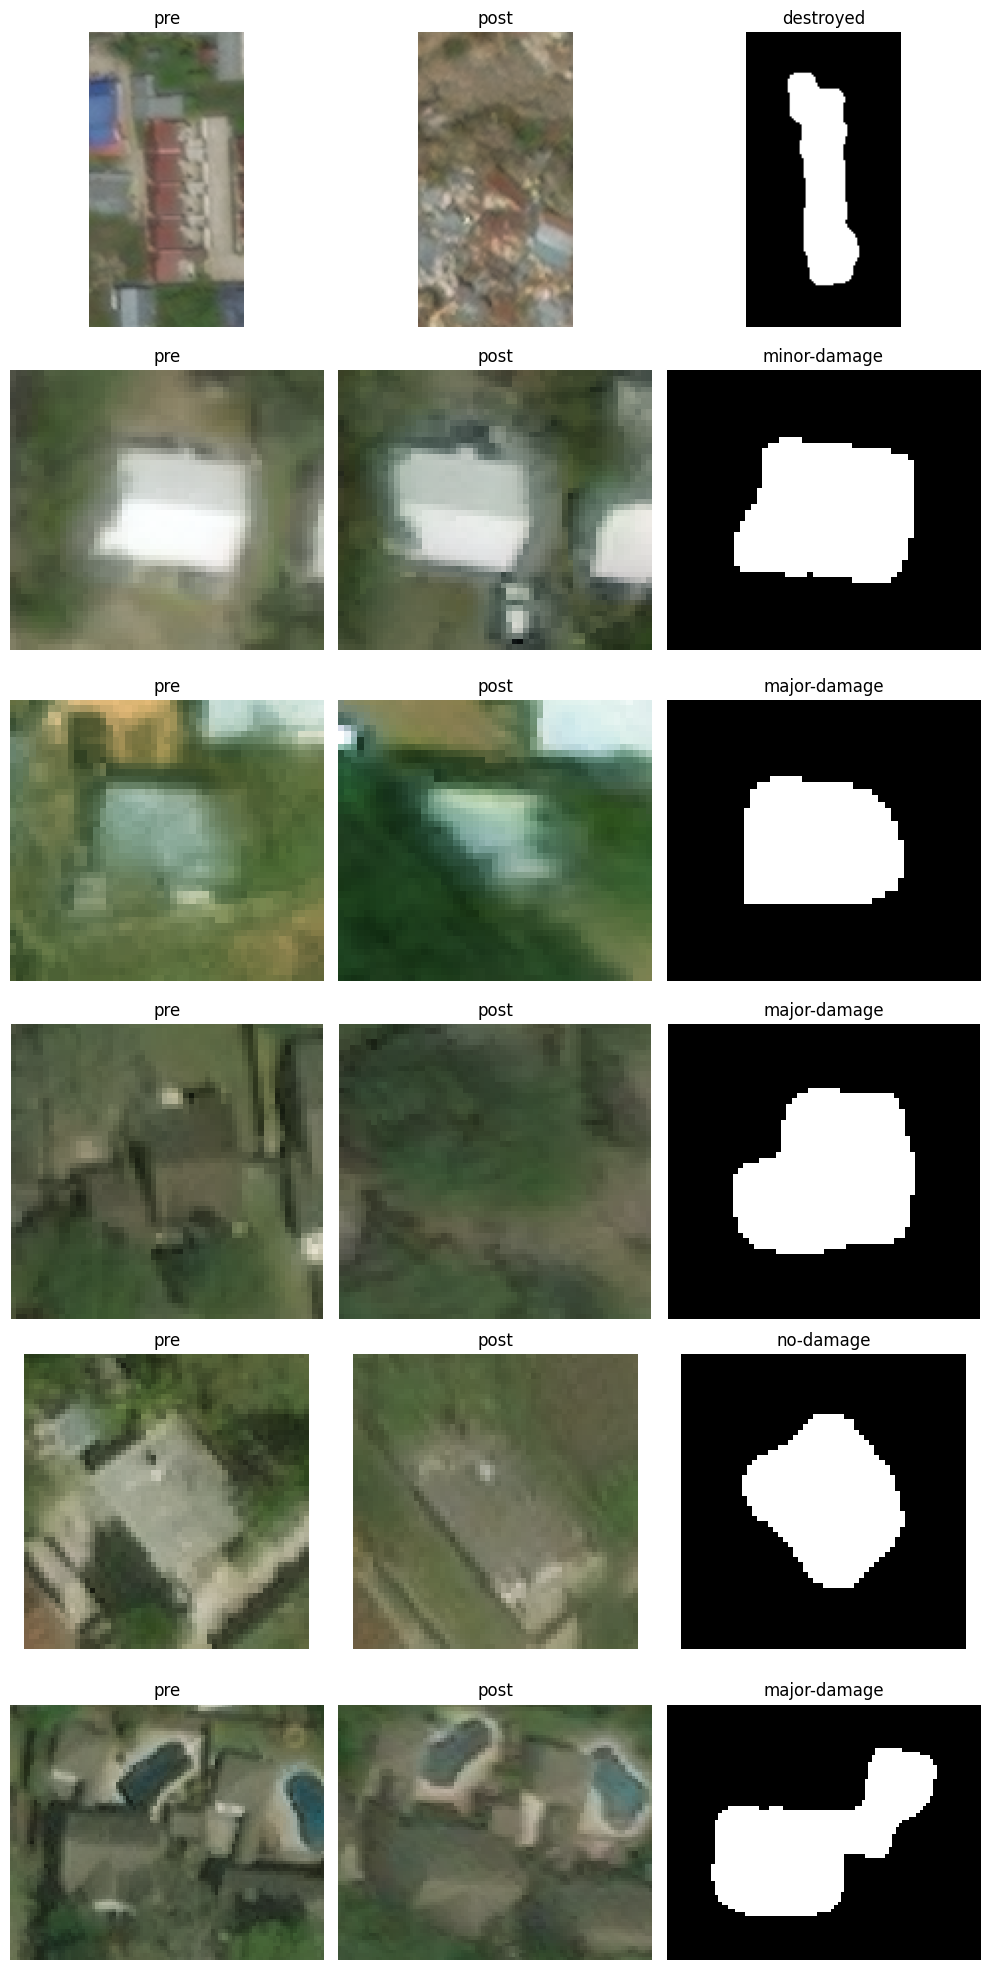

In [ ]:
sample_df = predobj_df.sample(6, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(6, 3, figsize=(10, 20))
for i in range(6):
    pre = np.array(Image.open(sample_df.iloc[i]["pre_crop_path"]).convert("RGB"))
    post = np.array(Image.open(sample_df.iloc[i]["post_crop_path"]).convert("RGB"))
    mask = np.array(Image.open(sample_df.iloc[i]["mask_crop_path"]).convert("L"))

    axes[i, 0].imshow(pre)
    axes[i, 0].set_title("pre")
    axes[i, 1].imshow(post)
    axes[i, 1].set_title("post")
    axes[i, 2].imshow(mask, cmap="gray")
    axes[i, 2].set_title(sample_df.iloc[i]["label_name"])

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

## **Classifier Data Pipeline**

Define augmentations and build the dataset used by the Siamese building-level classifier.

In [ ]:
cls_train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.2),
    A.Resize(CLS_IMG_SIZE, CLS_IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
], additional_targets={"image_post": "image", "mask": "mask"})

cls_val_transform = A.Compose([
    A.Resize(CLS_IMG_SIZE, CLS_IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
], additional_targets={"image_post": "image", "mask": "mask"})

class XBDPredictedObjectDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pre = np.array(Image.open(row["pre_crop_path"]).convert("RGB"))
        post = np.array(Image.open(row["post_crop_path"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_crop_path"]).convert("L"))

        aug = self.transform(image=pre, image_post=post, mask=mask)

        pre_t = aug["image"]
        post_t = aug["image_post"]
        mask_t = aug["mask"]

        if mask_t.ndim == 2:
            mask_t = mask_t.unsqueeze(0)
        mask_t = (mask_t > 0).float()

        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return pre_t, post_t, mask_t, label

## **Classifier Loaders and Class Weights**

Prepare dataloaders and compute class weights for imbalance-aware classifier training.

In [ ]:
cls_train_ds = XBDPredictedObjectDataset(train_crop_df, cls_train_transform)
cls_val_ds = XBDPredictedObjectDataset(val_crop_df, cls_val_transform)
cls_test_ds = XBDPredictedObjectDataset(test_crop_df, cls_val_transform)

train_labels = train_crop_df["label"].values
cls_class_counts = np.bincount(train_labels, minlength=DAMAGE_NUM_CLASSES).astype(np.float64)

cls_alpha = cls_class_counts.sum() / np.maximum(cls_class_counts, 1.0)
cls_alpha = cls_alpha / cls_alpha.mean()
cls_alpha_t = torch.tensor(cls_alpha, dtype=torch.float32, device=DEVICE)

print("Class counts:", cls_class_counts.astype(int))
print("Focal alpha:", cls_alpha)

cls_train_loader = DataLoader(
    cls_train_ds,
    batch_size=CLS_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

cls_val_loader = DataLoader(
    cls_val_ds,
    batch_size=CLS_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

cls_test_loader = DataLoader(
    cls_test_ds,
    batch_size=CLS_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

Class counts: [38890  6619  6970  5193]
Focal alpha: [0.20056093 1.17839771 1.11905515 1.50198622]


## **Siamese Building Classifier**

Define the EfficientNet-based Siamese classifier and initialize its encoder from the trained localization model.

In [ ]:
class SiameseEfficientNetClassifier(nn.Module):
    def __init__(self, backbone="efficientnet_b1", num_classes=4, drop_rate=0.3):
        super().__init__()

        self.encoder = timm.create_model(
            backbone,
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )
        feat_dim = self.encoder.num_features

        self.head = nn.Sequential(
            nn.BatchNorm1d(feat_dim * 3),
            nn.Dropout(drop_rate),
            nn.Linear(feat_dim * 3, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, pre, post, mask):
        if mask.shape[-2:] != pre.shape[-2:]:
            mask = F.interpolate(mask, size=pre.shape[-2:], mode="nearest")

        attn = 0.35 + 0.65 * mask
        pre = pre * attn
        post = post * attn

        f_pre = self.encoder(pre)
        f_post = self.encoder(post)

        feat = torch.cat([f_pre, f_post, torch.abs(f_post - f_pre)], dim=1)
        return self.head(feat)

In [ ]:
def init_classifier_from_localization_encoder(cls_model, loc_model):
    loc_enc_state = loc_model.encoder.state_dict()
    msg = cls_model.encoder.load_state_dict(loc_enc_state, strict=False)
    print("Classifier encoder initialized from localization encoder.")
    print(msg)

In [ ]:
loc_model.load_state_dict(torch.load(LOC_SAVE_PATH_DRIVE, map_location=DEVICE))
loc_model.eval()

cls_model = SiameseEfficientNetClassifier(
    backbone=BACKBONE,
    num_classes=DAMAGE_NUM_CLASSES,
    drop_rate=0.3
).to(DEVICE)

init_classifier_from_localization_encoder(cls_model, loc_model)

cls_loss_fn = nn.CrossEntropyLoss(weight=cls_alpha_t)

cls_optimizer = torch.optim.AdamW(
    cls_model.parameters(),
    lr=CLS_LR,
    weight_decay=CLS_WEIGHT_DECAY
)

cls_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cls_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

cls_scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

Classifier encoder initialized from localization encoder.
_IncompatibleKeys(missing_keys=['conv_head.weight', 'bn2.weight', 'bn2.bias', 'bn2.running_mean', 'bn2.running_var'], unexpected_keys=[])


## **Train Building-Level Classifier**

Train the predicted-object Siamese classifier, monitor validation macro-F1, and save the best checkpoint.

In [ ]:
def run_cls_epoch(loader, train=True):
    cls_model.train() if train else cls_model.eval()

    total_loss = 0.0
    cm = np.zeros((DAMAGE_NUM_CLASSES, DAMAGE_NUM_CLASSES), dtype=np.int64)

    pbar = tqdm(loader, desc="Cls Train" if train else "Cls Val", leave=False)

    for pre_imgs, post_imgs, masks, labels in pbar:
        pre_imgs = pre_imgs.to(DEVICE, non_blocking=True)
        post_imgs = post_imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if train:
            cls_optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = cls_model(pre_imgs, post_imgs, masks)

            loss = cls_loss_fn(logits.float(), labels)

            if train:
                cls_scaler.scale(loss).backward()
                cls_scaler.step(cls_optimizer)
                cls_scaler.update()

        total_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        targets = labels.detach().cpu().numpy()
        cm += confusion_matrix(targets,preds,labels=list(range(DAMAGE_NUM_CLASSES)))

    avg_loss = total_loss / len(loader.dataset)
    macro_f1, per_class_f1 = macro_f1_from_cm(cm)

    return {
        "loss": avg_loss,
        "macro_f1": macro_f1,
        "per_class_f1": per_class_f1,
        "cm": cm
    }

In [ ]:
best_cls_val = -1
best_cls_epoch = -1
epochs_no_improve = 0

cls_history = {
    "train_loss": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_macro_f1": []
}

for epoch in range(CLS_EPOCHS):
    train_metrics = run_cls_epoch(cls_train_loader, train=True)
    val_metrics = run_cls_epoch(cls_val_loader, train=False)

    cls_scheduler.step(val_metrics["macro_f1"])

    cls_history["train_loss"].append(train_metrics["loss"])
    cls_history["train_macro_f1"].append(train_metrics["macro_f1"])
    cls_history["val_loss"].append(val_metrics["loss"])
    cls_history["val_macro_f1"].append(val_metrics["macro_f1"])

    print(
        f"[CLS] Epoch {epoch+1:02d}/{CLS_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_cls_val:
        best_cls_val = val_metrics["macro_f1"]
        best_cls_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(cls_model.state_dict(), CLS_SAVE_PATH)
        print(f"Saved best classifier model to {CLS_SAVE_PATH}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CLS_EARLY_STOP_PATIENCE:
        print("Early stopping triggered.")
        break

print("Best classifier epoch:", best_cls_epoch)
print("Best classifier val macro F1:", best_cls_val)

[CLS] Epoch 01/25 | train_loss=0.8752 | train_macro_f1=0.5648 | val_loss=0.8749 | val_macro_f1=0.5733
Saved best classifier model to /content/best_model1c_siamese_classifier.pth


[CLS] Epoch 02/25 | train_loss=0.7241 | train_macro_f1=0.6519 | val_loss=0.8049 | val_macro_f1=0.5696


[CLS] Epoch 03/25 | train_loss=0.6724 | train_macro_f1=0.6736 | val_loss=0.7023 | val_macro_f1=0.6152
Saved best classifier model to /content/best_model1c_siamese_classifier.pth


[CLS] Epoch 04/25 | train_loss=0.6428 | train_macro_f1=0.6847 | val_loss=0.6634 | val_macro_f1=0.6407
Saved best classifier model to /content/best_model1c_siamese_classifier.pth


[CLS] Epoch 05/25 | train_loss=0.6138 | train_macro_f1=0.6961 | val_loss=0.6737 | val_macro_f1=0.6461
Saved best classifier model to /content/best_model1c_siamese_classifier.pth


...

[CLS] Epoch 13/25 | train_loss=0.4844 | train_macro_f1=0.7528 | val_loss=0.6202 | val_macro_f1=0.6771


[CLS] Epoch 14/25 | train_loss=0.4670 | train_macro_f1=0.7569 | val_loss=0.6464 | val_macro_f1=0.6673


[CLS] Epoch 15/25 | train_loss=0.3975 | train_macro_f1=0.7874 | val_loss=0.6807 | val_macro_f1=0.6599


[CLS] Epoch 16/25 | train_loss=0.3610 | train_macro_f1=0.8034 | val_loss=0.6770 | val_macro_f1=0.6676


[CLS] Epoch 17/25 | train_loss=0.3349 | train_macro_f1=0.8153 | val_loss=0.7532 | val_macro_f1=0.6516
Early stopping triggered.
Best classifier epoch: 11
Best classifier val macro F1: 0.6810625600806147


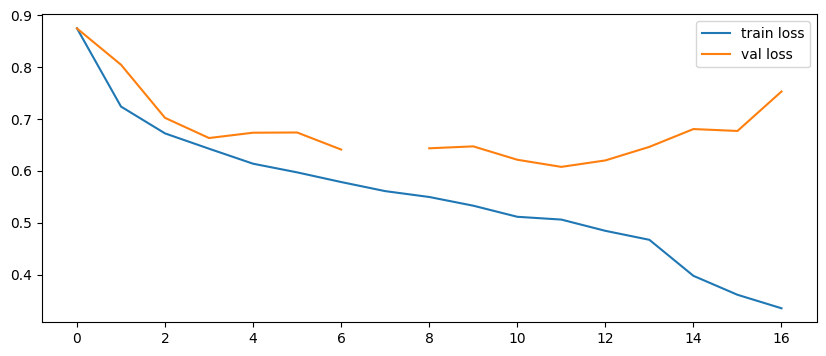

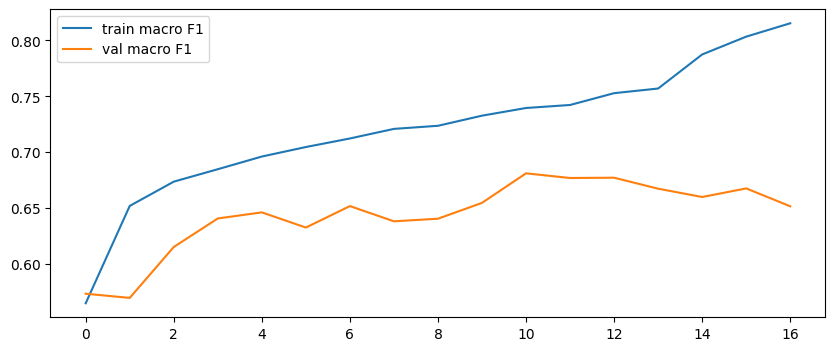

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(cls_history["train_loss"], label="train loss")
plt.plot(cls_history["val_loss"], label="val loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cls_history["train_macro_f1"], label="train macro F1")
plt.plot(cls_history["val_macro_f1"], label="val macro F1")
plt.legend()
plt.show()

## **Evaluate Building-Level Classifier**

Report test performance, including macro-F1, per-class F1, and a full classification report.

In [ ]:
cls_model.load_state_dict(torch.load(CLS_SAVE_PATH, map_location=DEVICE))
test_metrics = run_cls_epoch(cls_test_loader, train=False)

print("Test crop macro F1:", round(test_metrics["macro_f1"], 4))
print("Per-class F1:")
for name, f1 in zip(DAMAGE_CLASS_NAMES, test_metrics["per_class_f1"]):
    print(name, f"{f1:.4f}" if not np.isnan(f1) else "nan")

cm = test_metrics["cm"]
y_true = []
y_pred = []
for i in range(DAMAGE_NUM_CLASSES):
    for j in range(DAMAGE_NUM_CLASSES):
        y_true.extend([i] * cm[i, j])
        y_pred.extend([j] * cm[i, j])

print()
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(DAMAGE_NUM_CLASSES)),
    target_names=DAMAGE_CLASS_NAMES,
    digits=4,
    zero_division=0
))

Test crop macro F1: 0.6912
Per-class F1:
no-damage 0.8678
minor-damage 0.4920
major-damage 0.6699
destroyed 0.7350

              precision    recall  f1-score   support

   no-damage     0.9600    0.7919    0.8678      8355
minor-damage     0.4006    0.6375    0.4920      1600
major-damage     0.6322    0.7123    0.6699      1759
   destroyed     0.6457    0.8528    0.7350       917

    accuracy                         0.7657     12631
   macro avg     0.6596    0.7486    0.6912     12631
weighted avg     0.8206    0.7657    0.7830     12631



## **End-to-End Inference and Visualization**

Run the complete Model 1 pipeline on full tiles and visualize qualitative predictions from localization through final damage mapping.



In [ ]:
loc_model.load_state_dict(torch.load(LOC_SAVE_PATH_DRIVE, map_location=DEVICE))
cls_model.load_state_dict(torch.load(CLS_SAVE_PATH, map_location=DEVICE))
loc_model.eval()
cls_model.eval()

SiameseEfficientNetClassifier(
  (encoder): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
     

In [ ]:
@torch.no_grad()
def classify_building_component(pre_img_np, post_img_np, comp):
    out = make_context_crops(
        pre_img_np,
        post_img_np,
        comp["mask"],
        pad_frac=CONTEXT_PAD_FRAC,
        min_pad=CONTEXT_MIN_PAD
    )
    if out is None:
        return 0

    pre_crop, post_crop, mask_crop, _ = out

    aug = cls_val_transform(image=pre_crop, image_post=post_crop, mask=mask_crop)

    pre_t = aug["image"].unsqueeze(0).to(DEVICE)
    post_t = aug["image_post"].unsqueeze(0).to(DEVICE)
    mask_t = aug["mask"]
    if mask_t.ndim == 2:
        mask_t = mask_t.unsqueeze(0)
    mask_t = (mask_t > 0).float().unsqueeze(0).to(DEVICE)

    logits = cls_model(pre_t, post_t, mask_t)
    return torch.argmax(logits, dim=1)[0].item()

@torch.no_grad()
def run_model1_pipeline(row, min_area=COMP_MIN_AREA):
    pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
    post = np.array(Image.open(row["post_img"]).convert("RGB"))

    loc_mask = predict_loc_mask(row["pre_img"])
    loc_mask = clean_binary_mask(loc_mask)
    comps = connected_components_from_mask(loc_mask, min_area=min_area)

    damage_map = np.zeros(loc_mask.shape, dtype=np.uint8)

    for comp in comps:
        pred_cls = classify_building_component(pre, post, comp)
        damage_map[comp["mask"]] = pred_cls + 1

    return pre, post, loc_mask, damage_map

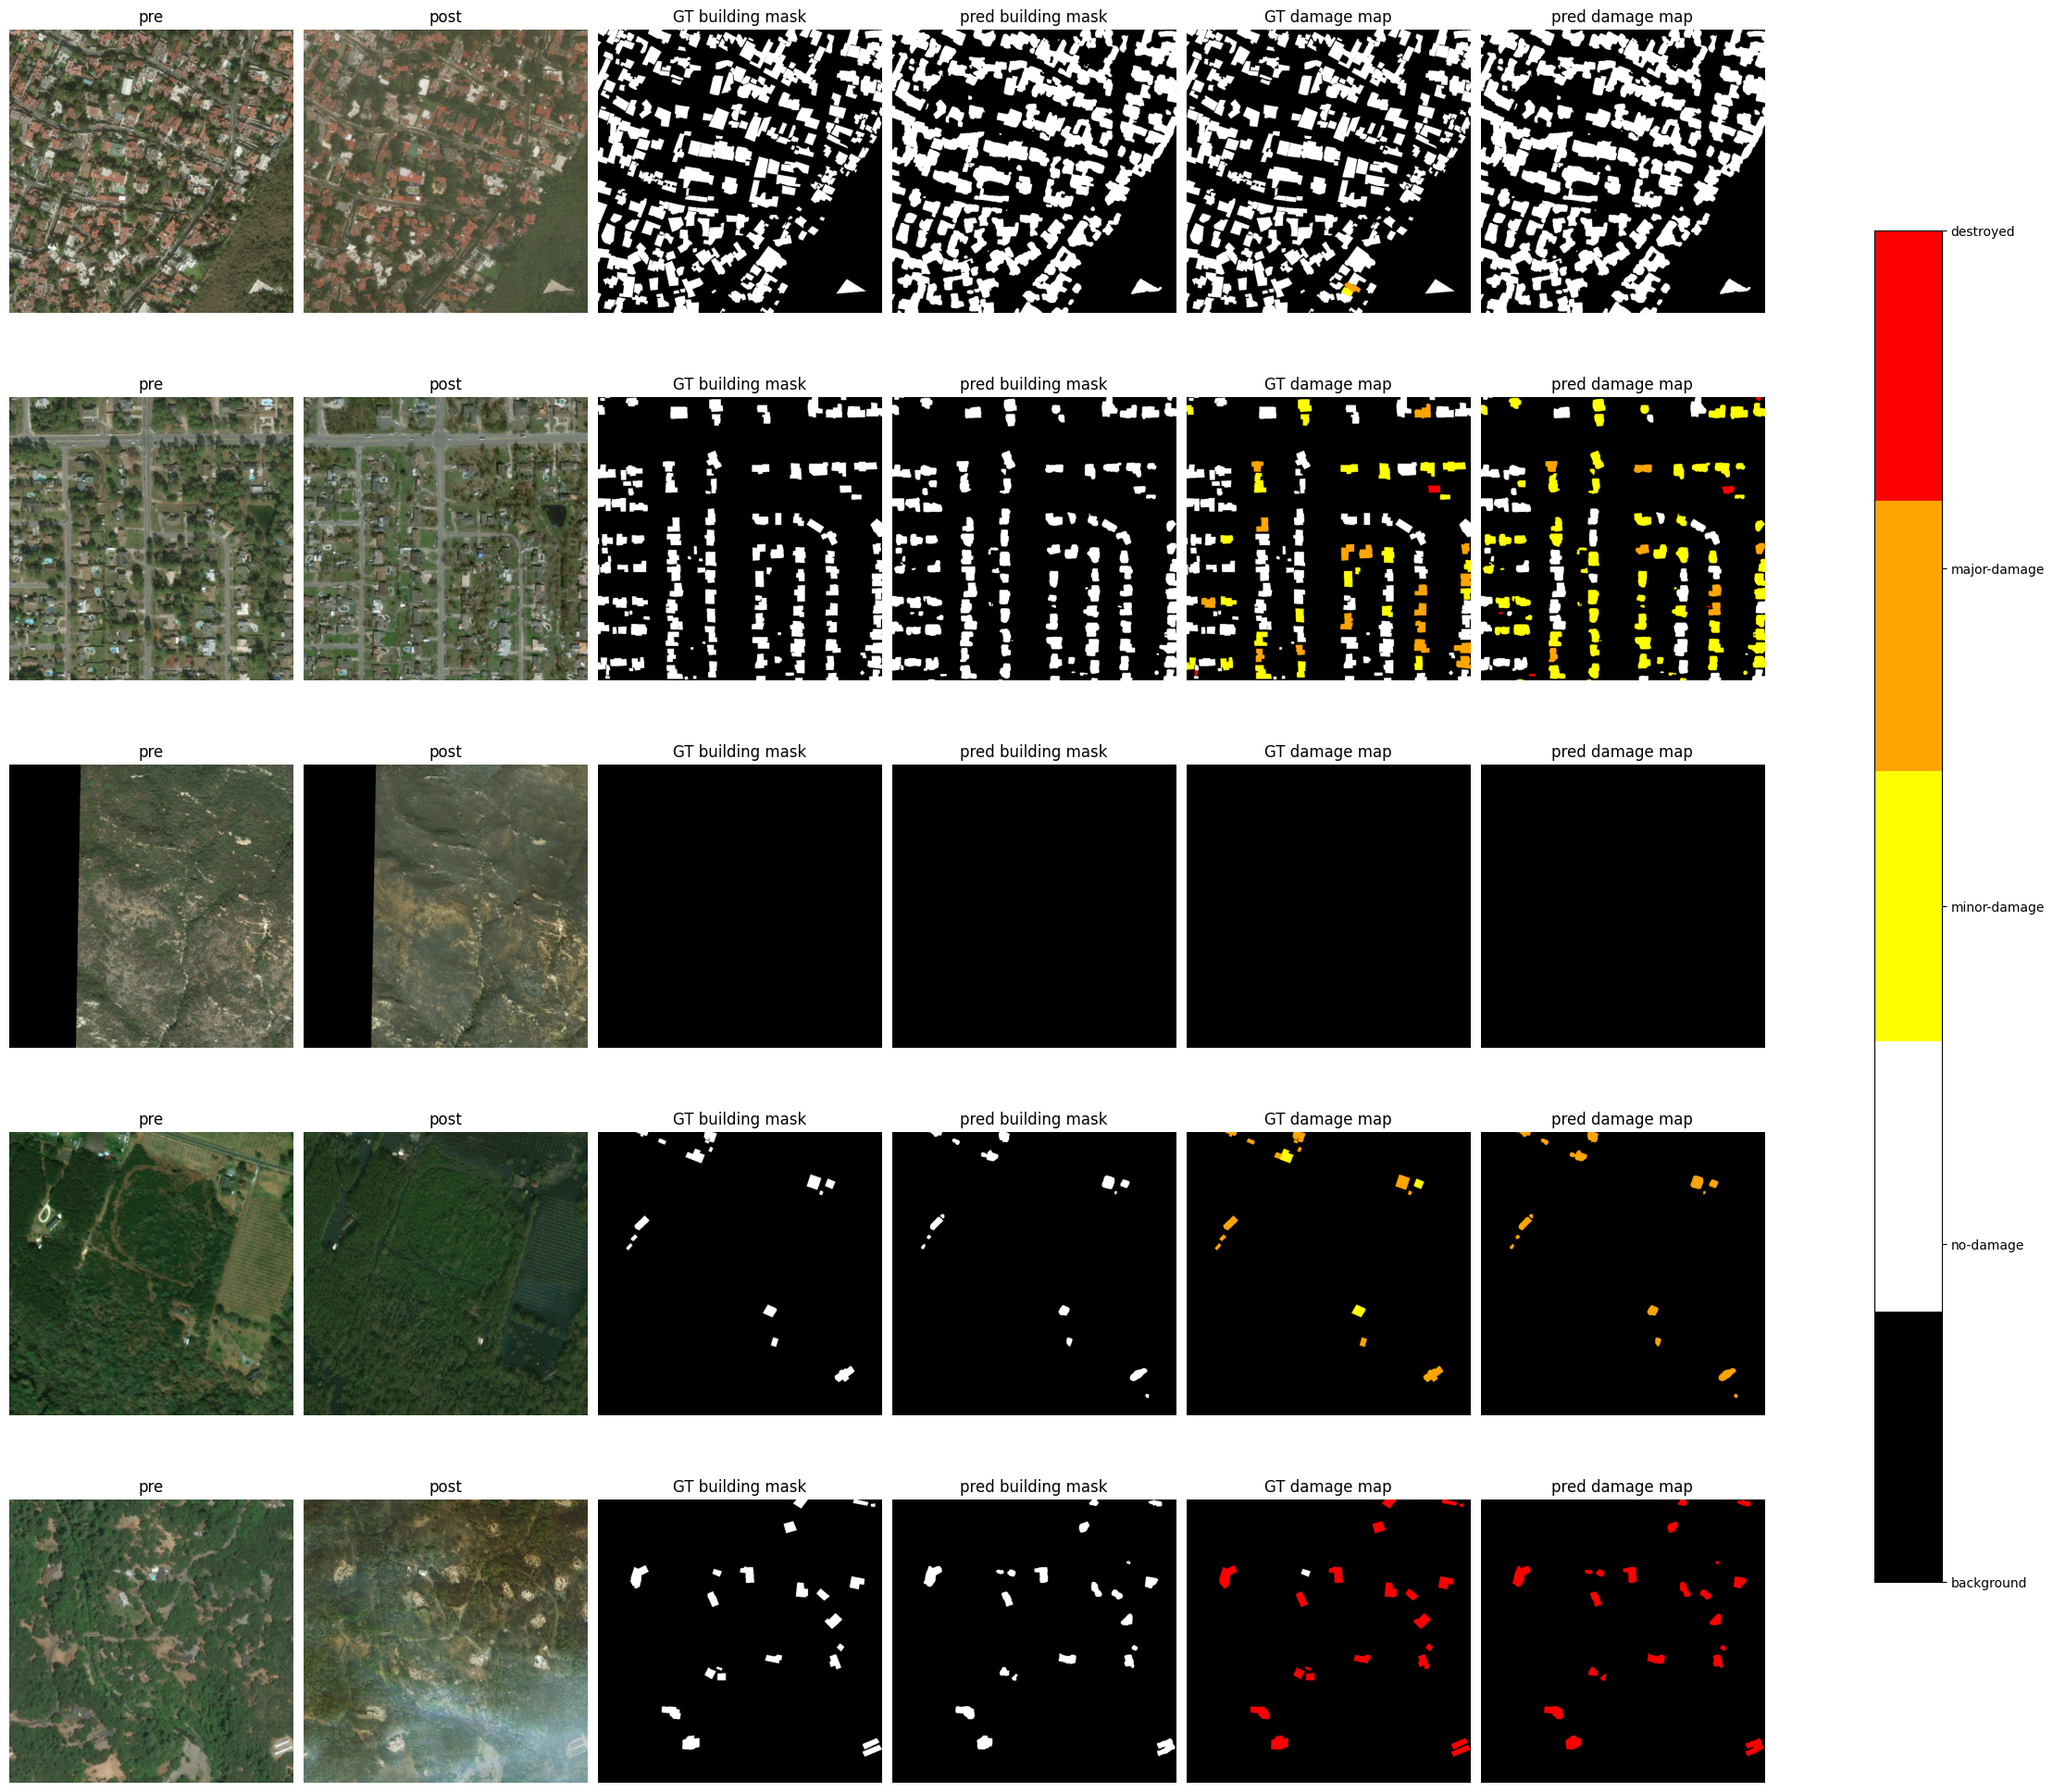

In [ ]:
damage_colors = ["black", "white", "yellow", "orange", "red"]
damage_cmap = ListedColormap(damage_colors)

def build_gt_damage_map(row):
    uid_map, meta = load_uid_to_feature(row["post_label_path"])
    h = int(meta["height"])
    w = int(meta["width"])

    gt_damage = np.zeros((h, w), dtype=np.uint8)

    for uid, feat in uid_map.items():
        subtype = feat["properties"]["subtype"]
        if subtype not in CLASS_NAME_TO_ID:
            continue

        cls_id = CLASS_NAME_TO_ID[subtype] + 1
        poly_mask = polygon_mask_from_wkt(feat["wkt"], h, w)
        gt_damage[poly_mask > 0] = cls_id

    return gt_damage

def build_gt_building_mask(row):
    uid_map, meta = load_uid_to_feature(row["post_label_path"])
    h = int(meta["height"])
    w = int(meta["width"])

    gt_mask = np.zeros((h, w), dtype=np.uint8)

    for uid, feat in uid_map.items():
        subtype = feat["properties"]["subtype"]
        if subtype not in CLASS_NAME_TO_ID:
            continue

        poly_mask = polygon_mask_from_wkt(feat["wkt"], h, w)
        gt_mask[poly_mask > 0] = 1

    return gt_mask

def show_model1_predictions(df_subset, n=5):
    n = min(n, len(df_subset))
    fig, axes = plt.subplots(n, 6, figsize=(24, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    im_gt = None
    im_pred = None

    for i in range(n):
        row = df_subset.iloc[i]

        pre, post, loc_mask, damage_map = run_model1_pipeline(row)
        gt_building_mask = build_gt_building_mask(row)
        gt_damage_map = build_gt_damage_map(row)

        axes[i, 0].imshow(pre)
        axes[i, 0].set_title("pre")

        axes[i, 1].imshow(post)
        axes[i, 1].set_title("post")

        axes[i, 2].imshow(gt_building_mask, cmap="gray")
        axes[i, 2].set_title("GT building mask")

        axes[i, 3].imshow(loc_mask, cmap="gray")
        axes[i, 3].set_title("pred building mask")

        im_gt = axes[i, 4].imshow(gt_damage_map, cmap=damage_cmap, vmin=0, vmax=4)
        axes[i, 4].set_title("GT damage map")

        im_pred = axes[i, 5].imshow(damage_map, cmap=damage_cmap, vmin=0, vmax=4)
        axes[i, 5].set_title("pred damage map")

        for j in range(6):
            axes[i, j].axis("off")

    plt.tight_layout()

    cbar = fig.colorbar(
        im_pred,
        ax=axes.ravel().tolist(),
        orientation="vertical",
        shrink=0.75
    )
    cbar.set_ticks(np.arange(5))
    cbar.set_ticklabels(["background"] + DAMAGE_CLASS_NAMES)

    plt.show()

show_model1_predictions(test_df, n=5)